In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('ml_df.xlsx')

In [3]:
df.head()

,Unnamed: 0,Amount,TransactionHour,IsWeekend,AccountAgeDays,PrevTxn24H,AvgCustomerAmount,AmountDeviation,MerchantRiskScore,DeviceChanged,...,PaymentMethod_Wallet,DeviceType_Mac,DeviceType_Windows,DeviceType_iPhone,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,0,503.13,10,0,1359,0,441.11,0.14,0.16,0,...,False,False,True,False,False,False,False,False,True,False
1,1,2360.42,18,0,1072,1,2439.00,-0.03,0.97,0,...,False,False,False,True,False,False,False,True,False,False
2,2,1940.09,20,0,228,2,2080.68,-0.07,0.50,0,...,False,False,False,False,False,False,False,False,True,False
3,3,1452.12,11,0,725,3,765.94,0.90,0.93,1,...,True,False,False,True,False,False,False,True,False,False
4,4,519.49,8,1,403,2,3362.47,-0.85,0.93,0,...,False,False,False,False,False,False,True,False,False,False


In [6]:
df= df.drop(columns = ['Unnamed: 0'])

In [7]:
X = df.drop("IsFraud", axis=1)

y = df["IsFraud"]

In [8]:
y.value_counts()

IsFraud
0    9555
1     445
Name: count, dtype: int64

In [10]:
y.value_counts(normalize=True)*100

IsFraud
0    95.55
1     4.45
Name: proportion, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
numerical_cols = [
'Amount',
'TransactionHour',
'AccountAgeDays',
'PrevTxn24H',
'AvgCustomerAmount',
'AmountDeviation',
'MerchantRiskScore',
'AmountRatio',
'AbsoluteDeviation',
'CompositeRiskScore'
]

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

## LOGISTIC REGRESSION

In [14]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

In [15]:
lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', random_state=42)

In [16]:
y_pred_lr = lr.predict(X_test_scaled)

In [18]:
y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:,1]

## DECISION TREE

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X, y, threshold=0.05):

    # Fraud probabilities
    y_prob = model.predict_proba(X)[:, 1]

    # Convert probabilities into predictions
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\nEvaluation using Threshold = {threshold}")
    print("-"*50)

    print(classification_report(y, y_pred, zero_division=0))

    print(f"Accuracy : {accuracy_score(y, y_pred):.4f}")
    print(f"Precision: {precision_score(y, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y, y_prob):.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y, y_pred))

In [39]:
evaluate_model(dt, X_test, y_test)


Evaluation using Threshold = 0.05
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.19      0.31      1911
           1       0.04      0.70      0.07        89

    accuracy                           0.21      2000
   macro avg       0.48      0.44      0.19      2000
weighted avg       0.89      0.21      0.30      2000

Accuracy : 0.2100
Precision: 0.0384
Recall   : 0.6966
F1 Score : 0.0728
ROC AUC  : 0.5916

Confusion Matrix
[[ 358 1553]
 [  27   62]]


## RANDOM FOREST

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight = "balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [40]:
evaluate_model(rf, X_test, y_test)


Evaluation using Threshold = 0.05
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      0.68      0.80      1911
           1       0.09      0.64      0.15        89

    accuracy                           0.68      2000
   macro avg       0.53      0.66      0.48      2000
weighted avg       0.94      0.68      0.77      2000

Accuracy : 0.6815
Precision: 0.0861
Recall   : 0.6404
F1 Score : 0.1518
ROC AUC  : 0.7294

Confusion Matrix
[[1306  605]
 [  32   57]]



Threshold = 0.03
Precision : 0.07668711656441718
Recall    : 0.8426966292134831
F1 Score  : 0.14058106841611998

Threshold = 0.05
Precision : 0.08610271903323263
Recall    : 0.6404494382022472
F1 Score  : 0.151797603195739

Threshold = 0.07
Precision : 0.08928571428571429
Recall    : 0.449438202247191
F1 Score  : 0.148975791433892

Threshold = 0.1
Precision : 0.09565217391304348
Recall    : 0.24719101123595505
F1 Score  : 0.13793103448275862

Threshold = 0.12
Precision : 0.09868421052631579
Recall    : 0.16853932584269662
F1 Score  : 0.12448132780082988

Threshold = 0.15
Precision : 0.13333333333333333
Recall    : 0.11235955056179775
F1 Score  : 0.12195121951219512

Threshold = 0.2
Precision : 0.29411764705882354
Recall    : 0.056179775280898875
F1 Score  : 0.09433962264150944


              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1911
           1       0.00      0.00      0.00        89

    accuracy                           0.96      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.91      0.96      0.93      2000

Accuracy : 0.9555
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.7294257374514196
[[1911    0]
 [  89    0]]


D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undefine

## XGBOOST

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
evaluate_model(xgb, X_test, y_test)


Evaluation using Threshold = 0.05
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1911
           1       0.10      0.21      0.13        89

    accuracy                           0.88      2000
   macro avg       0.53      0.56      0.53      2000
weighted avg       0.92      0.88      0.90      2000

Accuracy : 0.8750
Precision: 0.0955
Recall   : 0.2135
F1 Score : 0.1319
ROC AUC  : 0.6745

Confusion Matrix
[[1731  180]
 [  70   19]]


In [30]:
y_train.value_counts()

IsFraud
0    7644
1     356
Name: count, dtype: int64

In [31]:
y_test.value_counts()

IsFraud
0    1911
1      89
Name: count, dtype: int64

In [34]:
print(y_train.value_counts())

print(y_train.value_counts(normalize=True))

print(rf.predict_proba(X_test)[:,1][:20])

print(rf.get_params())

IsFraud
0    7644
1     356
Name: count, dtype: int64
IsFraud
0    0.9555
1    0.0445
Name: proportion, dtype: float64
[0.035 0.055 0.    0.015 0.1   0.005 0.005 0.065 0.005 0.005 0.005 0.055
 0.065 0.005 0.015 0.04  0.02  0.03  0.12  0.015]
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


## COMPARISION BETWEEN MODELS

In [42]:
def compare_models(model, X, y, threshold=0.05):

    y_prob = model.predict_proba(X)[:,1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "ROC_AUC": roc_auc_score(y, y_prob)
    }

In [43]:
results = pd.DataFrame({
    "Logistic Regression": compare_models(lr, X_test_scaled, y_test),
    "Decision Tree": compare_models(dt, X_test, y_test),
    "Random Forest": compare_models(rf, X_test, y_test),
    "XGBoost": compare_models(xgb, X_test, y_test)
}).T

results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.0450,0.044522,1.000000,0.085249,0.758565
Decision Tree,0.2100,0.038390,0.696629,0.072770,0.591625
Random Forest,0.6815,0.086103,0.640449,0.151798,0.729426
XGBoost,0.8750,0.095477,0.213483,0.131944,0.674522


### Even though Logistic Regression has a slightly higher ROC-AUC, Random Forest has the highest F1-score,

## FEATURE IMPORTANCE

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                     Feature  Importance
7          MerchantRiskScore    0.091357
18        CompositeRiskScore    0.073112
1            TransactionHour    0.071808
5          AvgCustomerAmount    0.067250
3             AccountAgeDays    0.066010
0                     Amount    0.055823
13               AmountRatio    0.054845
17         AbsoluteDeviation    0.052317
6            AmountDeviation    0.048997
14          HighRiskMerchant    0.044522
10                     Month    0.039291
4                 PrevTxn24H    0.031512
11        IsNightTransaction    0.023563
23  MerchantCategory_Jewelry    0.020155
8              DeviceChanged    0.016595
9            LocationChanged    0.015515
45         DeviceType_iPhone    0.009038
42      PaymentMethod_Wallet    0.008830
39  PaymentMethod_Debit Card    0.008792
43            DeviceType_Mac    0.008227


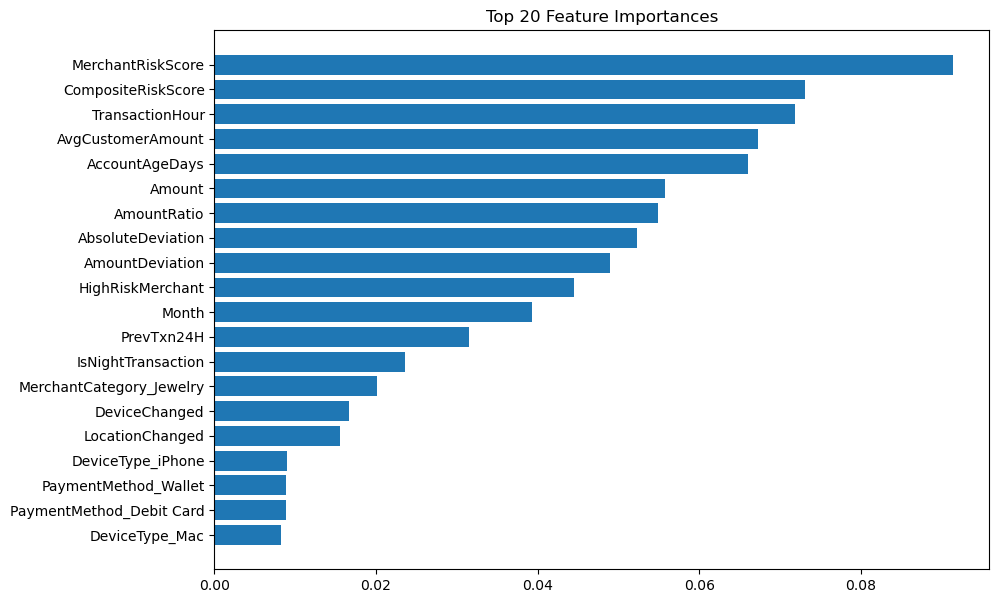

In [45]:
top20 = importance.head(20)

plt.figure(figsize=(10,7))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.show()

In [46]:
y_test.values

array([0, 1, 0, ..., 0, 0, 0], shape=(2000,))

#### Generate risk scores to flag risks

In [47]:
results = X_test.copy()

results["ActualFraud"] = y_test.values

results["FraudProbability"] = rf.predict_proba(X_test)[:,1]

In [48]:
results["RiskScore"] = (
    results["FraudProbability"]*100
).round(2)

In [49]:
high = results["RiskScore"].quantile(.95)

medium = results["RiskScore"].quantile(.80)

In [50]:
def bucket(score):

    if score >= high:
        return "High Risk"

    elif score >= medium:
        return "Medium Risk"

    else:
        return "Low Risk"



In [51]:

results["RiskBucket"] = results["RiskScore"].apply(bucket)

In [52]:
results.head()

,Amount,TransactionHour,IsWeekend,AccountAgeDays,PrevTxn24H,AvgCustomerAmount,AmountDeviation,MerchantRiskScore,DeviceChanged,LocationChanged,...,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,ActualFraud,FraudProbability,RiskScore,RiskBucket
3986,79.72,4,1,1148,2,545.74,-0.85,0.14,0,0,...,False,True,False,False,False,False,0,0.035,3.5,Low Risk
4061,4216.76,14,0,1910,6,3331.40,0.27,0.63,0,0,...,False,False,False,False,False,False,1,0.055,5.5,Low Risk
3978,3602.07,11,1,364,5,2792.19,0.29,0.32,0,0,...,False,False,True,False,False,False,0,0.000,0.0,Low Risk
8004,2533.43,13,0,761,3,2556.71,-0.01,0.75,0,0,...,False,False,False,False,False,True,0,0.015,1.5,Low Risk
2645,2698.74,3,1,2175,2,1320.17,1.04,0.90,1,0,...,False,True,False,False,False,False,1,0.100,10.0,Medium Risk


In [56]:
df_original = pd.read_excel("Synthetic_Transaction_Risk_Dataset.xlsx")

In [57]:
df_original["CompositeRiskScore"] = df["CompositeRiskScore"]

In [58]:
merchant_summary = df_original.groupby("MerchantCategory").agg(
    TotalTransactions=("IsFraud","count"),
    FraudTransactions=("IsFraud","sum"),
    AvgAmount=("Amount","mean"),
    AvgRisk=("CompositeRiskScore","mean")
)

merchant_summary["FraudRate"] = (
    merchant_summary["FraudTransactions"] /
    merchant_summary["TotalTransactions"]
)

In [59]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!streamlit hello

In [ ]:
import joblib

joblib.dump(rf,"fraud_model.pkl")